L'objectif ici est de se placer purement en vision métier : on s'intéresse à définir le risque d'un encours réel
C'est-à-dire que je vais uniquement regarder les clients ayant un BILL_AMT1 > 0.  
Nous sortons ainsi de l'apprentissage :
- les clients sans dette à prédire
- les clients inactifs
- les clients sortis du circuit de gestion classique pour lequels nous n'avons pas le suivi des paiements et des encours de manière correcte

In [1]:
import pandas as pd
from pathlib import Path

# 1. Dossier courant du notebook
current_dir = Path.cwd()

# 2. Retrouve automatiquement la racine du projet (là où se trouve le dossier 'data')
# Remonte l'arborescence jusqu'à trouver le dossier 'data'
root_dir = next(
    p for p in [current_dir] + list(current_dir.parents) if (p / "data").exists()
)

# 3. Chemin vers le fichier
file_path = root_dir / "data" / "creditcard_pret_ingestion.csv"

# 4. Chargement du CSV
df = pd.read_csv(file_path)

In [2]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm'],
      dtype='str')

In [3]:
# on filtre le dataset utilisé de sorte à ne garder que la population souhaitée : BILL_AMT1 > 0
df= df[(df['BILL_AMT1']>0)]

In [4]:
# Analyse de la distribution de la variable cible dp_nm
print("=== ANALYSE DE LA DISTRIBUTION DE dpnm ===")

# Compter les occurrences de chaque valeur
target_counts = df['dpnm'].value_counts()
print("\nNombre d'observations par classe :")
print(target_counts)

# Calculer les proportions
target_proportions = df['dpnm'].value_counts(normalize=True)
print("\nProportion de chaque classe :")
print(target_proportions)

# Afficher les pourcentages
print("\nPourcentage de chaque classe :")
for class_label, count in target_counts.items():
    percentage = (count / len(df)) * 100
    print(f"Classe {class_label}: {count} observations ({percentage:.2f}%)")

# Vérification si le dataset est équilibré
print("\n=== ÉQUILIBRE DU DATASET ===")
imbalance_ratio = target_counts.min() / target_counts.max()
print(f"Ratio d'équilibre (min/max): {imbalance_ratio:.3f}")

print("\n=== RÉSUMÉ ===")
print(f"Total d'observations : {len(df)}")
print(f"Classes présentes : {sorted(target_counts.index.tolist())}")

=== ANALYSE DE LA DISTRIBUTION DE dpnm ===

Nombre d'observations par classe :
dpnm
0    21409
1     5993
Name: count, dtype: int64

Proportion de chaque classe :
dpnm
0    0.781293
1    0.218707
Name: proportion, dtype: float64

Pourcentage de chaque classe :
Classe 0: 21409 observations (78.13%)
Classe 1: 5993 observations (21.87%)

=== ÉQUILIBRE DU DATASET ===
Ratio d'équilibre (min/max): 0.280

=== RÉSUMÉ ===
Total d'observations : 27402
Classes présentes : [0, 1]


In [5]:
from sklearn.model_selection import train_test_split

# Séparation test / entrainement
y = df['dpnm']
X = df.drop('dpnm', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [6]:
# Séparation des colonnes numériques et catégorielles
num_col = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
cat_col = ['SEX', 'EDUCATION', 'MARRIAGE']
ord_col = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

Je commence par un apprentissage sur le F1 score

In [7]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC

# 0. Réinitialisation impérative des index
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# 1. Calcul dynamique du pourcentage de la classe 1
percentage = (y_train == 1).mean() * 100
scale_pos = (100 - percentage) / percentage

# 2. Transformateur complet avec gestion des catégories inconnues en validation
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_col),
        (
            'nom',
            OneHotEncoder(
                drop='first', sparse_output=False, handle_unknown='ignore'
            ),
            cat_col,
        ),
        (
            'ord',
            OrdinalEncoder(
                handle_unknown='use_encoded_value', unknown_value=-1
            ),
            ord_col,
        ),
    ]
)

# 3. Dictionnaire des modèles
models = {
    'LogisticRegression': make_pipeline(
        preprocessor,
        LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=42
        ),
    ),
    'SVM': make_pipeline(
        preprocessor,
        CalibratedClassifierCV(
            estimator=SVC(class_weight='balanced', random_state=42),
            ensemble=False,
        ),
    ),
    'MLPClassifier': make_pipeline(
        preprocessor,
        MLPClassifier(
            hidden_layer_sizes=(50, 25),
            max_iter=500,
            random_state=42,
            early_stopping=True,
        ),
    ),
    'KNN': make_pipeline(
        preprocessor, KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    ),
    'RandomForest': make_pipeline(
        preprocessor,
        RandomForestClassifier(
            class_weight='balanced', random_state=42, n_jobs=-1
        ),
    ),
    'CatBoost': make_pipeline(
        preprocessor,
        CatBoostClassifier(
            scale_pos_weight=scale_pos,
            random_state=42,
            verbose=0,
            thread_count=-1,
        ),
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
importances_dict = {}
fitted_models = {}

print('Spot-check avec mesure du surapprentissage & extraction des poids...\n')

# 4. Boucle d'évaluation
for name, model in models.items():
    # A. Évaluation CV
    cv_res = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1',
        return_train_score=True,
        error_score='raise',  # Relève directement l'exception si un pli échoue
        n_jobs=-1,
    )

    train_score = np.mean(cv_res['train_score'])
    test_score = np.mean(cv_res['test_score'])

    results.append({
        'Modèle': name,
        'F1 Train': round(train_score, 4),
        'F1 Val (Validation)': round(test_score, 4),
        'Écart (Overfit)': round(train_score - test_score, 4),
        'Std Val': round(np.std(cv_res['test_score']), 4),
    })

    # B. Fit final sur l'ensemble X_train
    model.fit(X_train, y_train)
    fitted_models[name] = model

    # C. Extraction des poids d'importance
    clf = model[-1]

    if isinstance(clf, CalibratedClassifierCV):
        clf_estimator = (
            clf.calibrated_classifiers_[0].estimator
            if hasattr(clf, 'calibrated_classifiers_')
            else clf.estimator
        )
    else:
        clf_estimator = clf

    if hasattr(clf_estimator, 'feature_importances_'):
        raw_imp = clf_estimator.feature_importances_
    elif hasattr(clf_estimator, 'coef_'):
        raw_imp = np.abs(clf_estimator.coef_[0])
    elif hasattr(clf_estimator, 'coefs_'):
        raw_imp = np.abs(clf_estimator.coefs_[0]).sum(axis=1)
    else:
        print(
            f"  -> {name} : pas de poids d'importance natifs."
        )
        continue

    total = raw_imp.sum()
    importances_dict[name] = (raw_imp / total) * 100 if total > 0 else raw_imp

# 5. Affichage des résultats du Spot-Check
df_results = pd.DataFrame(results).sort_values(
    by='F1 Val (Validation)', ascending=False
)
print("\n--- RÉSULTATS DU SPOT-CHECK ET CONTRÔLE DE L'OVERFITTING ---")
print(df_results.to_string(index=False))

# 6. Extraction dynamique des noms de features transformées
premier_pipeline = list(fitted_models.values())[0]
transformed_features = premier_pipeline[0].get_feature_names_out()
clean_features = [
    f.replace('num__', '').replace('nom__', '').replace('ord__', '')
    for f in transformed_features
]

df_importances = pd.DataFrame(importances_dict, index=clean_features)
if not df_importances.empty:
    df_importances['Moyenne (%)'] = df_importances.mean(axis=1)
    df_importances = df_importances.sort_values(
        by='Moyenne (%)', ascending=False
    ).round(2)

    print('\n--- IMPORTANCE DES FEATURES SELON CHAQUE MODÈLE (%) ---')
    print(df_importances.to_string())

Spot-check avec mesure du surapprentissage & extraction des poids...



  -> SVM : pas de poids d'importance natifs.


  -> KNN : pas de poids d'importance natifs.



--- RÉSULTATS DU SPOT-CHECK ET CONTRÔLE DE L'OVERFITTING ---
            Modèle  F1 Train  F1 Val (Validation)  Écart (Overfit)  Std Val
          CatBoost    0.7032               0.5536           0.1496   0.0098
               SVM    0.5683               0.5417           0.0265   0.0174
      RandomForest    0.9936               0.5362           0.4574   0.0150
LogisticRegression    0.5076               0.5058           0.0018   0.0102
     MLPClassifier    0.4866               0.4686           0.0180   0.0322
               KNN    0.5898               0.4565           0.1333   0.0203

--- IMPORTANCE DES FEATURES SELON CHAQUE MODÈLE (%) ---
             LogisticRegression  MLPClassifier  RandomForest  CatBoost  Moyenne (%)
PAY_1                     13.25           4.71         12.06     12.98        10.75
EDUCATION_4               26.31           5.18          0.16      0.71         8.09
BILL_AMT1                  5.69           4.07          6.19      7.79         5.93
LIMIT_BAL    

Je fais un apprentissage sur le ROC AUC cette fois

In [8]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC

# 0. Réinitialisation impérative des index
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# 1. Calcul dynamique du ratio pour déséquilibre de classes
percentage = (y_train == 1).mean() * 100
scale_pos = (100 - percentage) / percentage

# 2. Transformateur complet sécurisé
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_col),
        (
            'nom',
            OneHotEncoder(
                drop='first', sparse_output=False, handle_unknown='ignore'
            ),
            cat_col,
        ),
        (
            'ord',
            OrdinalEncoder(
                handle_unknown='use_encoded_value', unknown_value=-1
            ),
            ord_col,
        ),
    ]
)

# 3. Dictionnaire des modèles
models = {
    'LogisticRegression': make_pipeline(
        preprocessor,
        LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=42
        ),
    ),
    'SVM': make_pipeline(
        preprocessor,
        CalibratedClassifierCV(
            estimator=SVC(class_weight='balanced', random_state=42),
            ensemble=False,
        ),
    ),
    'MLPClassifier': make_pipeline(
        preprocessor,
        MLPClassifier(
            hidden_layer_sizes=(50, 25),
            max_iter=500,
            random_state=42,
            early_stopping=True,
        ),
    ),
    'KNN': make_pipeline(
        preprocessor, KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    ),
    'RandomForest': make_pipeline(
        preprocessor,
        RandomForestClassifier(
            class_weight='balanced', random_state=42, n_jobs=-1
        ),
    ),
    'CatBoost': make_pipeline(
        preprocessor,
        CatBoostClassifier(
            scale_pos_weight=scale_pos,
            random_state=42,
            verbose=0,
            thread_count=-1,
        ),
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
importances_dict = {}
fitted_models = {}

print('Spot-check ROC AUC & extraction des poids...\n')

# 4. Boucle d'évaluation sur ROC AUC
for name, model in models.items():
    # A. Évaluation CV (ROC AUC)
    cv_res = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc',
        return_train_score=True,
        error_score='raise',
        n_jobs=-1,
    )

    train_score = np.mean(cv_res['train_score'])
    test_score = np.mean(cv_res['test_score'])

    results.append({
        'Modèle': name,
        'ROC AUC Train': round(train_score, 4),
        'ROC AUC Val (Validation)': round(test_score, 4),
        'Écart (Overfit)': round(train_score - test_score, 4),
        'Std Val': round(np.std(cv_res['test_score']), 4),
    })

    # B. Fit final sur l'ensemble X_train
    model.fit(X_train, y_train)
    fitted_models[name] = model

    # C. Extraction des poids d'importance
    clf = model[-1]

    if isinstance(clf, CalibratedClassifierCV):
        clf_estimator = (
            clf.calibrated_classifiers_[0].estimator
            if hasattr(clf, 'calibrated_classifiers_')
            else clf.estimator
        )
    else:
        clf_estimator = clf

    if hasattr(clf_estimator, 'feature_importances_'):
        raw_imp = clf_estimator.feature_importances_
    elif hasattr(clf_estimator, 'coef_'):
        raw_imp = np.abs(clf_estimator.coef_[0])
    elif hasattr(clf_estimator, 'coefs_'):
        raw_imp = np.abs(clf_estimator.coefs_[0]).sum(axis=1)
    else:
        print(
            f"  -> {name} : pas de poids d'importance natifs."
        )
        continue

    total = raw_imp.sum()
    importances_dict[name] = (raw_imp / total) * 100 if total > 0 else raw_imp

# 5. Affichage des résultats du Spot-Check ROC AUC
df_results_auc = pd.DataFrame(results).sort_values(
    by='ROC AUC Val (Validation)', ascending=False
)
print("\n--- RÉSULTATS DU SPOT-CHECK (ROC AUC) ET CONTRÔLE DE L'OVERFITTING ---")
print(df_results_auc.to_string(index=False))

# 6. Extraction dynamique des noms de features transformées
premier_pipeline = list(fitted_models.values())[0]
transformed_features = premier_pipeline[0].get_feature_names_out()
clean_features = [
    f.replace('num__', '').replace('nom__', '').replace('ord__', '')
    for f in transformed_features
]

df_importances = pd.DataFrame(importances_dict, index=clean_features)
if not df_importances.empty:
    df_importances['Moyenne (%)'] = df_importances.mean(axis=1)
    df_importances = df_importances.sort_values(
        by='Moyenne (%)', ascending=False
    ).round(2)

    print('\n--- IMPORTANCE DES FEATURES SELON CHAQUE MODÈLE (%) ---')
    print(df_importances.to_string())

Spot-check ROC AUC & extraction des poids...



  -> SVM : pas de poids d'importance natifs.


  -> KNN : pas de poids d'importance natifs.



--- RÉSULTATS DU SPOT-CHECK (ROC AUC) ET CONTRÔLE DE L'OVERFITTING ---
            Modèle  ROC AUC Train  ROC AUC Val (Validation)  Écart (Overfit)  Std Val
          CatBoost         0.9204                    0.7865           0.1339   0.0074
      RandomForest         1.0000                    0.7798           0.2202   0.0084
     MLPClassifier         0.7919                    0.7753           0.0166   0.0135
               SVM         0.8008                    0.7707           0.0302   0.0091
LogisticRegression         0.7455                    0.7440           0.0016   0.0113
               KNN         0.8892                    0.7188           0.1704   0.0129

--- IMPORTANCE DES FEATURES SELON CHAQUE MODÈLE (%) ---
             LogisticRegression  MLPClassifier  RandomForest  CatBoost  Moyenne (%)
PAY_1                     13.25           4.71         12.06     12.98        10.75
EDUCATION_4               26.31           5.18          0.16      0.71         8.09
BILL_AMT1        

KNN reste en retrait sur les 2 évaluations  
RandomForest apprend par coeur, il doit etre bridé au niveau de la profondeur  
Catboost est le modèle le plus performant dans les 2 cas mais souffre d'un peu de surapprentissage  
MLPClassifier s'en sort très bien au niveau du ROC AUC tout comme SVM.  
Logisticregression est stable  

On tente d'améliorer les hyperparamètres sur les modèles restants en se basant sur les 2 types de score : le ROC AUC et le F1 score

In [9]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC

# 1. Calcul dynamique du déséquilibre de classe
percentage = (y_train == 1).mean() * 100
scale_pos = (100 - percentage) / percentage

# 2. Transformateur complet avec gestion d'erreurs sur catégories inconnues
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_col),
        (
            'nom',
            OneHotEncoder(sparse_output=False, handle_unknown='ignore'),
            cat_col,
        ),
        (
            'ord',
            OrdinalEncoder(
                handle_unknown='use_encoded_value', unknown_value=-1
            ),
            ord_col,
        ),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Modèles et grilles d'hyperparamètres
experiments = {
    'LogisticRegression': {
        'pipeline': make_pipeline(
            preprocessor,
            LogisticRegression(
                max_iter=1000, class_weight='balanced', random_state=42
            ),
        ),
        'params': {
            'logisticregression__C': [0.01, 0.1, 1.0, 10.0],
        },
    },
    'SVM': {
        'pipeline': make_pipeline(
            preprocessor,
            CalibratedClassifierCV(
                estimator=SVC(class_weight='balanced', random_state=42),
                ensemble=False,
            ),
        ),
        'params': {
            'calibratedclassifiercv__estimator__C': [0.5, 1, 2],
            'calibratedclassifiercv__estimator__gamma': ['scale', 'auto'],
        },
    },
    'MLPClassifier': {
        'pipeline': make_pipeline(
            preprocessor,
            MLPClassifier(max_iter=500, random_state=42, early_stopping=True),
        ),
        'params': {
            'mlpclassifier__hidden_layer_sizes': [(32, 16), (64, 32), (32,)],
            'mlpclassifier__alpha': [0.01, 0.1, 1.0],
        },
    },
    'KNN': {
        'pipeline': make_pipeline(
            preprocessor,
            KNeighborsClassifier(n_jobs=-1),
        ),
        'params': {
            'kneighborsclassifier__n_neighbors': [3, 5, 7, 11, 15],
            'kneighborsclassifier__weights': ['uniform', 'distance'],
        },
    },
    'RandomForest': {
        'pipeline': make_pipeline(
            preprocessor,
            RandomForestClassifier(
                class_weight='balanced', random_state=42, n_jobs=-1
            ),
        ),
        'params': {
            'randomforestclassifier__max_depth': [6, 8, 10],
            'randomforestclassifier__min_samples_leaf': [20, 50, 100],
            'randomforestclassifier__n_estimators': [200, 300],
        },
    },
    'CatBoost': {
        'pipeline': make_pipeline(
            preprocessor,
            CatBoostClassifier(
                scale_pos_weight=scale_pos,
                random_state=42,
                verbose=0,
                thread_count=-1,
            ),
        ),
        'params': {
            'catboostclassifier__depth': [4, 6],
            'catboostclassifier__l2_leaf_reg': [5, 10, 15],
            'catboostclassifier__learning_rate': [0.03, 0.05],
        },
    },
}

# Structure de stockage des résultats
best_models = {'roc_auc': {}, 'f1': {}}
grid_results = {'roc_auc': [], 'f1': []}

# 4. Exécution de l'optimisation
for metric in ['roc_auc', 'f1']:
    print(f'Optimisation avec le scoring : {metric.upper()}...\n')

    for name, exp in experiments.items():
        grid = GridSearchCV(
            estimator=exp['pipeline'],
            param_grid=exp['params'],
            cv=cv,
            scoring=metric,
            return_train_score=True,
            n_jobs=-1,
        )
        grid.fit(X_train, y_train)

        best_models[metric][name] = grid.best_estimator_

        best_idx = grid.best_index_
        train_score = grid.cv_results_['mean_train_score'][best_idx]
        val_score = grid.cv_results_['mean_test_score'][best_idx]
        val_std = grid.cv_results_['std_test_score'][best_idx]

        grid_results[metric].append({
            'Modèle': name,
            'Score Train': round(train_score, 4),
            'Score Val': round(val_score, 4),
            'Écart (Overfit)': round(train_score - val_score, 4),
            'Std Val': round(val_std, 4),
            'Meilleurs Paramètres': grid.best_params_,
        })

# 5. Sauvegarde des tableaux de résultats par métrique (utilisés en aval : matrices
#    de confusion en validation et comparatif final Train/Val/Test) + affichage des synthèses
grid_results_df = {}

for metric in ['roc_auc', 'f1']:
    df_res = pd.DataFrame(grid_results[metric]).sort_values(
        by='Score Val', ascending=False
    )
    grid_results_df[metric] = df_res

    print(f"\n================ RÉSULTATS OPTIMISÉS ({metric.upper()}) ================")
    print(
        df_res[
            ['Modèle', 'Score Train', 'Score Val', 'Écart (Overfit)', 'Std Val']
        ].to_string(index=False)
    )

    print(f"\n--- MEILLEURS HYPERPARAMÈTRES ({metric.upper()}) ---")
    for row in grid_results[metric]:
        print(f"\n[{row['Modèle']}]")
        for param, val in row['Meilleurs Paramètres'].items():
            clean_param = param.split('__')[-1]
            print(f'  - {clean_param}: {val}')

# Tableaux "post-tuning" exposés pour la suite du notebook (cellules confusion matrix / comparatif final)
df_grid_f1 = grid_results_df['f1'].set_index('Modèle')
df_grid_auc = grid_results_df['roc_auc'].set_index('Modèle')


Optimisation avec le scoring : ROC_AUC...



Optimisation avec le scoring : F1...




================ RÉSULTATS OPTIMISÉS (ROC_AUC) ================
            Modèle  Score Train  Score Val  Écart (Overfit)  Std Val
      RandomForest       0.8503     0.7927           0.0576   0.0067
          CatBoost       0.8521     0.7914           0.0607   0.0072
     MLPClassifier       0.8037     0.7817           0.0220   0.0095
               SVM       0.8004     0.7711           0.0292   0.0091
               KNN       0.8328     0.7503           0.0825   0.0119
LogisticRegression       0.7455     0.7440           0.0016   0.0112

--- MEILLEURS HYPERPARAMÈTRES (ROC_AUC) ---

[LogisticRegression]
  - C: 10.0

[SVM]
  - C: 0.5
  - gamma: auto

[MLPClassifier]
  - alpha: 0.01
  - hidden_layer_sizes: (64, 32)

[KNN]
  - n_neighbors: 15
  - weights: uniform

[RandomForest]
  - max_depth: 10
  - min_samples_leaf: 20
  - n_estimators: 300

[CatBoost]
  - depth: 4
  - l2_leaf_reg: 15
  - learning_rate: 0.03

================ RÉSULTATS OPTIMISÉS (F1) ================
            Mod

Je regarde maintenant les matrices de confusion sur les meilleurs modèles


=== IMPORTANCE DES FEATURES (Optimisé ROC AUC) ===
             LogisticRegression  MLPClassifier  RandomForest  CatBoost  Moyenne (%)
PAY_1                     10.32           3.56         29.81     31.24        18.73
EDUCATION_4               19.01           4.09          0.03      0.79         5.98
PAY_2                      2.16           3.29         14.06      2.58         5.52
LIMIT_BAL                  3.76           3.28          5.70      8.24         5.25
BILL_AMT1                  4.47           3.55          2.65      6.83         4.38
PAY_3                      1.83           3.06          7.98      2.81         3.92
PAY_AMT2                   3.56           3.45          3.28      4.11         3.60
PAY_4                      2.66           3.64          5.64      2.25         3.55
SEX_2                      9.68           3.90          0.21      0.28         3.52
PAY_AMT1                   2.56           3.41          3.68      4.01         3.41
SEX_1                   

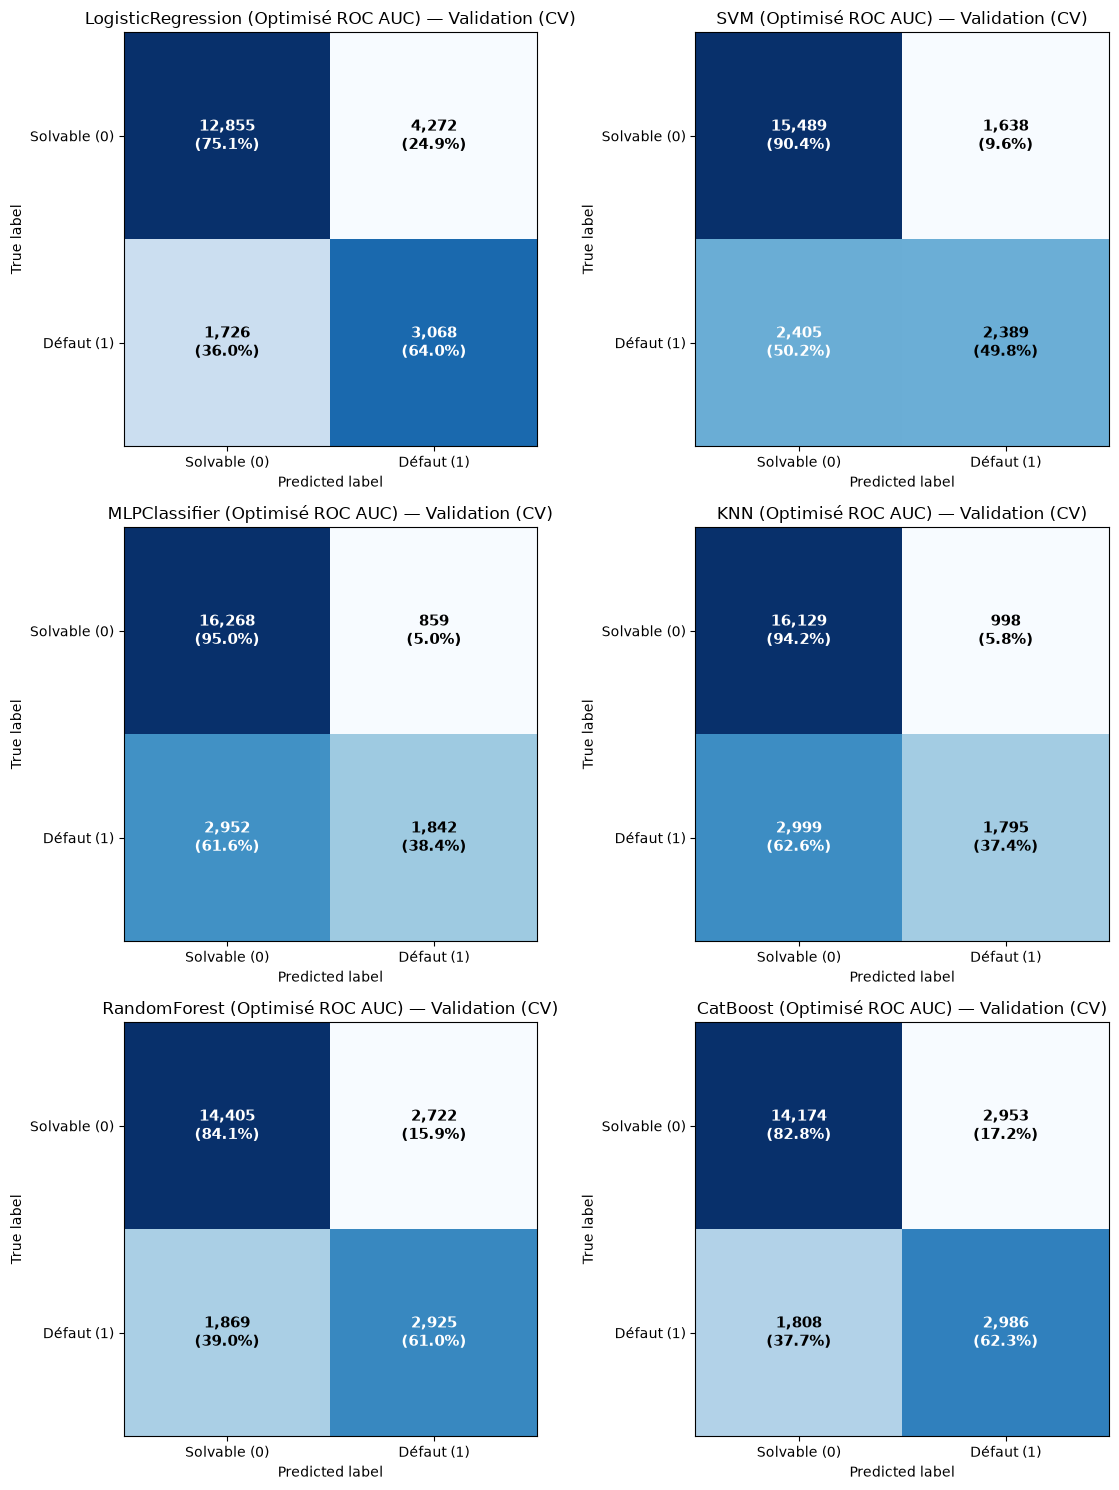


=== IMPORTANCE DES FEATURES (Optimisé F1-Score) ===
             LogisticRegression  MLPClassifier  RandomForest  CatBoost  Moyenne (%)
PAY_1                     18.06          12.27         34.82     29.05        23.55
PAY_2                      4.25           6.20         17.19      2.43         7.52
LIMIT_BAL                  6.61           3.97          5.30      7.93         5.95
PAY_3                      3.49           5.78          9.88      2.57         5.43
PAY_4                      4.56           6.29          6.81      2.48         5.04
BILL_AMT1                  5.38           4.14          1.24      6.99         4.44
PAY_5                      3.46           4.96          6.06      1.37         3.96
PAY_AMT2                   5.61           3.24          2.70      4.28         3.96
PAY_AMT1                   4.01           3.54          3.21      3.98         3.68
EDUCATION_4               10.17           3.49          0.03      0.93         3.66
PAY_6                  

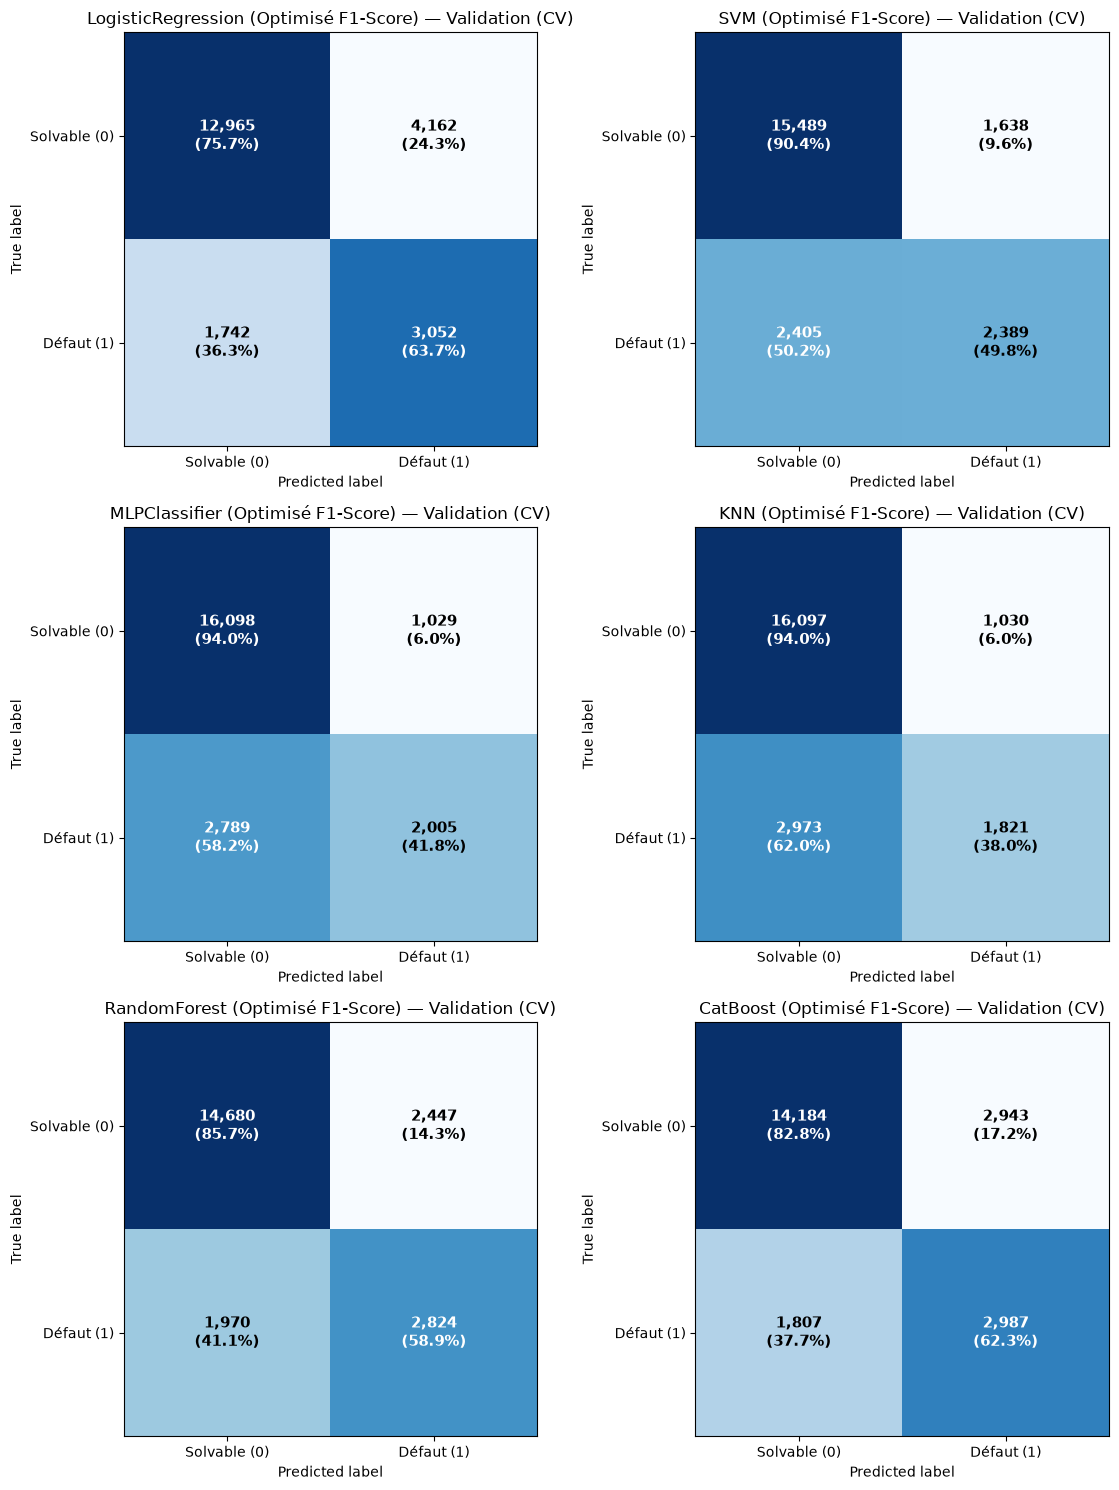

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_predict


def analyser_modeles(dict_modeles, titre_metric):
    # A. Importances de variables
    importances_dict = {}

    # 1. Extraction dynamique des vrais noms de features après transformation
    premier_pipeline = list(dict_modeles.values())[0]
    transformed_features = premier_pipeline[0].get_feature_names_out()
    clean_features = [
        f.replace("num__", "").replace("nom__", "").replace("ord__", "")
        for f in transformed_features
    ]

    for name, model in dict_modeles.items():
        clf = model[-1]

        if isinstance(clf, CalibratedClassifierCV):
            clf_estimator = (
                clf.calibrated_classifiers_[0].estimator
                if hasattr(clf, "calibrated_classifiers_")
                else clf.estimator
            )
        else:
            clf_estimator = clf

        if hasattr(clf_estimator, "feature_importances_"):
            raw_imp = clf_estimator.feature_importances_
        elif hasattr(clf_estimator, "coef_"):
            raw_imp = np.abs(clf_estimator.coef_[0])
        elif hasattr(clf_estimator, "coefs_"):
            raw_imp = np.abs(clf_estimator.coefs_[0]).sum(axis=1)
        else:
            continue

        total = raw_imp.sum()
        importances_dict[name] = (
            (raw_imp / total) * 100 if total > 0 else raw_imp
        )

    # 2. DataFrame construit avec le bon index (clean_features)
    df_imp = pd.DataFrame(importances_dict, index=clean_features)
    if not df_imp.empty:
        df_imp["Moyenne (%)"] = df_imp.mean(axis=1)
        df_imp = df_imp.sort_values(by="Moyenne (%)", ascending=False).round(2)

        print(f"\n=== IMPORTANCE DES FEATURES ({titre_metric}) ===")
        print(df_imp.to_string())

    # B. Matrices de confusion EN VALIDATION CROISÉE + Stockage des Rappels Validation
    #
    # Les modèles reçus (dict_modeles) sont déjà entraînés sur X_train en entier
    # (grid.best_estimator_), mais cross_validate/GridSearchCV ne conservent pas
    # les prédictions out-of-fold, seulement les scores agrégés. Pour afficher une
    # matrice de confusion représentative de la VALIDATION (et non un simple
    # rappel des données d'entraînement), on utilise cross_val_predict avec les
    # hyperparamètres déjà optimisés : chaque pli est prédit par un modèle qui ne
    # l'a jamais vu pendant son fit. Aucun nouvel entraînement final n'est refait
    # (pas de nouvelle recherche d'hyperparamètres) ; seul le refit par pli,
    # inhérent à toute validation croisée, a lieu ici.
    cv_cm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    n_models = len(dict_modeles)
    n_cols = 2 if n_models > 1 else 1
    n_rows = (n_models + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    axes = np.array(axes).flatten() if n_models > 1 else [axes]

    recalls_val = {}

    for idx, (name, model) in enumerate(dict_modeles.items()):
        # Prédictions out-of-fold (validation croisée), pas sur X_train directement
        y_pred = cross_val_predict(
            model, X_train, y_train, cv=cv_cm, n_jobs=-1
        )
        cm = confusion_matrix(y_train, y_pred)

        # Taux de correspondance par classe réelle (ligne)
        cm_rate = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

        # Récupération directe du Recall Validation (Ligne 1, Colonne 1)
        recalls_val[name] = cm_rate[1, 1]

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm_rate,
            display_labels=["Solvable (0)", "Défaut (1)"],
        )
        disp.plot(
            cmap="Blues",
            ax=axes[idx],
            colorbar=False,
            include_values=False,
        )

        # Injection des valeurs : Effectif + %
        for i in range(2):
            for j in range(2):
                count = cm[i, j]
                rate = cm_rate[i, j]
                text_label = f"{count:,}\n({rate:.1%})"

                color = "white" if rate > 0.5 else "black"
                axes[idx].text(
                    j,
                    i,
                    text_label,
                    ha="center",
                    va="center",
                    color=color,
                    fontweight="bold",
                    fontsize=11,
                )

        axes[idx].set_title(f"{name} ({titre_metric}) — Validation (CV)")

    for idx in range(n_models, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()

    return recalls_val


# Exécution et récupération des rappels (calculés en validation croisée)
recalls_val_auc = analyser_modeles(best_models['roc_auc'], "Optimisé ROC AUC")
recalls_val_f1 = analyser_modeles(best_models['f1'], "Optimisé F1-Score")


MLPClassifier semble doué pour détecter les vrais clients solvables, ce qui n'est pas le but recherché ici, il ne peut pas compenser via un hyperparamètre le déséquilibre de classe, on pourrait lui diminuer le seuil de décision ou faire un entrainement particulier compute_sample_weight pour compenser le déséquilibre

## Test final sur X_test

In [11]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, recall_score, roc_auc_score

print("=== ÉVALUATION FINALE MULTI-TABLEAUX (X_TEST VS VALIDATION CV POST-TUNING) ===\n")


def generer_tableaux_analyse(
    dict_best_models, df_cv_results, dict_recalls_val, metric_name
):
    # df_cv_results est indexé par 'Modèle' et contient la colonne 'Score Val'
    # = score de VALIDATION croisée du meilleur jeu d'hyperparamètres (post-tuning,
    # cellule GridSearchCV), et non un score d'entraînement.
    cv_map = df_cv_results
    score_col = "Score Val"

    target_rows = []
    recall_rows = []

    for model_name, model in dict_best_models.items():
        # 1. Prédictions sur X_test
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)

        # 2. Métriques sur Test
        test_target = (
            roc_auc_score(y_test, y_pred_proba)
            if metric_name == "ROC AUC"
            else f1_score(y_test, y_pred)
        )
        test_recall = recall_score(y_test, y_pred)

        # 3. Récupération du score de Validation CV (post-tuning) et du Recall Validation
        cv_target = cv_map.loc[model_name, score_col]
        val_recall = dict_recalls_val.get(model_name, np.nan)

        # 4. Calcul des écarts (Test vs Validation CV, plus Train vs Validation)
        diff_target = test_target - cv_target
        diff_recall = (
            (test_recall - val_recall) if pd.notna(val_recall) else np.nan
        )

        # Diagnostics
        diag_target = (
            "⚠️ Overfit"
            if diff_target < -0.05
            else ("📈 Sous-estimé" if diff_target > 0.05 else "✅ Stable")
        )
        diag_recall = (
            "⚠️ Chute Rappel"
            if pd.notna(diff_recall) and diff_recall < -0.04
            else "✅ Stable"
        )

        # Tableau 1 : Métrique Cible (Validation CV vs Test)
        target_rows.append({
            "Modèle": model_name,
            f"{metric_name} (Val CV)": round(cv_target, 4),
            f"{metric_name} (Test)": round(test_target, 4),
            "Diff Target": round(diff_target, 4),
            "Diagnostic": diag_target,
        })

        # Tableau 2 : Métrique Rappel (Validation CV vs Test)
        recall_rows.append({
            "Modèle": model_name,
            "Recall (Val CV)": (
                round(val_recall, 4) if pd.notna(val_recall) else "N/A"
            ),
            "Recall (Test)": round(test_recall, 4),
            "Diff Recall": (
                round(diff_recall, 4) if pd.notna(diff_recall) else "N/A"
            ),
            "Diagnostic": diag_recall,
        })

    return pd.DataFrame(target_rows), pd.DataFrame(recall_rows)


# ---------------------------------------------------------
# A. BLOC OPTIMISÉ POUR F1-SCORE
# ---------------------------------------------------------
df_f1_target, df_f1_recall = generer_tableaux_analyse(
    best_models['f1'], df_grid_f1, recalls_val_f1, "F1 Score"
)

print("=" * 65)
print("🎯 1. OPTIMISATION : F1-SCORE")
print("=" * 65)

print("\n--- Tableau 1A : Stabilité Métrique Cible (F1-Score, Val CV vs Test) ---")
print(df_f1_target.to_string(index=False))

print("\n--- Tableau 1B : Dérive du Rappel (Recall Val CV vs Test) ---")
print(df_f1_recall.to_string(index=False))

print("\n\n")

# ---------------------------------------------------------
# B. BLOC OPTIMISÉ POUR ROC AUC
# ---------------------------------------------------------
df_auc_target, df_auc_recall = generer_tableaux_analyse(
    best_models['roc_auc'], df_grid_auc, recalls_val_auc, "ROC AUC"
)

print("=" * 65)
print("🎯 2. OPTIMISATION : ROC AUC")
print("=" * 65)

print("\n--- Tableau 2A : Stabilité Métrique Cible (ROC AUC, Val CV vs Test) ---")
print(df_auc_target.to_string(index=False))

print("\n--- Tableau 2B : Dérive du Rappel (Recall Val CV vs Test) ---")
print(df_auc_recall.to_string(index=False))


=== ÉVALUATION FINALE MULTI-TABLEAUX (X_TEST VS VALIDATION CV POST-TUNING) ===



🎯 1. OPTIMISATION : F1-SCORE

--- Tableau 1A : Stabilité Métrique Cible (F1-Score, Val CV vs Test) ---
            Modèle  F1 Score (Val CV)  F1 Score (Test)  Diff Target Diagnostic
LogisticRegression             0.5083           0.4922      -0.0161   ✅ Stable
               SVM             0.5415           0.5357      -0.0058   ✅ Stable
     MLPClassifier             0.5120           0.5086      -0.0034   ✅ Stable
               KNN             0.4760           0.4696      -0.0064   ✅ Stable
      RandomForest             0.5610           0.5554      -0.0056   ✅ Stable
          CatBoost             0.5570           0.5540      -0.0030   ✅ Stable

--- Tableau 1B : Dérive du Rappel (Recall Val CV vs Test) ---
            Modèle  Recall (Val CV)  Recall (Test)  Diff Recall Diagnostic
LogisticRegression           0.6366         0.6205      -0.0161   ✅ Stable
               SVM           0.4983         0.5038       0.0054   ✅ Stable
     MLPClassifier           0.4182         0.4195      

🎯 2. OPTIMISATION : ROC AUC

--- Tableau 2A : Stabilité Métrique Cible (ROC AUC, Val CV vs Test) ---
            Modèle  ROC AUC (Val CV)  ROC AUC (Test)  Diff Target Diagnostic
LogisticRegression            0.7440          0.7309      -0.0131   ✅ Stable
               SVM            0.7711          0.7612      -0.0099   ✅ Stable
     MLPClassifier            0.7817          0.7713      -0.0104   ✅ Stable
               KNN            0.7503          0.7492      -0.0011   ✅ Stable
      RandomForest            0.7927          0.7884      -0.0043   ✅ Stable
          CatBoost            0.7914          0.7857      -0.0057   ✅ Stable

--- Tableau 2B : Dérive du Rappel (Recall Val CV vs Test) ---
            Modèle  Recall (Val CV)  Recall (Test)  Diff Recall Diagnostic
LogisticRegression           0.6400         0.6230      -0.0169   ✅ Stable
               SVM           0.4983         0.5038       0.0054   ✅ Stable
     MLPClassifier           0.3842         0.4204       0.0361   ✅ Stab

Pas de surapprentissage  
Attention : le recall sur MLPClassifier est dégradé, le réseau de neurones est à traiter peut etre à part

**Evolution par rapport à l'apprentissage initial**  
Augmentation généralisée des performances de tous les modèles d'environ 1 point  
ce n'est donc pas le fruit du hasard : les comptes avec encours nul ou négatif sont un réel bruit que les modèles n'arrivent pas à écarter  
malheureusement, je perds une partie de ma population d'entrainement dont des clients avec un comportement à étudier sur les mois précédents  
Moins de perte de performance lorsqu'on regarde le test